In [1]:
import tensorflow as tf
import requests
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess

from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

2026-02-03 11:58:40.682551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 11:58:40.711865: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 11:58:41.485921: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
r=requests.get('https://api.ipify.org?format=json')
j=r.json()
print(j)

{'ip': '67.102.242.118'}


In [3]:
# Load in the data
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x_train.shape:", x_train.shape)
print("x_test.shape:", x_test.shape)

x_train.shape: (60000, 28, 28)
x_test.shape: (10000, 28, 28)


In [4]:
# the data is only 2D!
# convolution expects height x width x color
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print(x_train.shape)

(60000, 28, 28, 1)


In [5]:
# number of classes
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [6]:
# Build the model using the functional API
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

I0000 00:00:1770101923.188227 1374135 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3718 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [7]:
# Compile and fit
# Note: make sure you are using the GPU for this!
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15


2026-02-03 11:58:44.433598: I external/local_xla/xla/service/service.cc:163] XLA service 0x71e5e400c960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-03 11:58:44.433613: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-02-03 11:58:44.451848: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-03 11:58:44.565431: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 130/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5144 - loss: 1.4110

I0000 00:00:1770101925.908529 1374533 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8129 - loss: 0.5056 - val_accuracy: 0.8546 - val_loss: 0.3881
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8681 - loss: 0.3506 - val_accuracy: 0.8778 - val_loss: 0.3338
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8843 - loss: 0.3047 - val_accuracy: 0.8808 - val_loss: 0.3158
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8973 - loss: 0.2717 - val_accuracy: 0.8906 - val_loss: 0.3016
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9070 - loss: 0.2443 - val_accuracy: 0.8952 - val_loss: 0.2852
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9159 - loss: 0.2232 - val_accuracy: 0.8974 - val_loss: 0.2850
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9204 - loss: 0.2081 - val_accuracy: 0.8925 - val_loss: 0.2949
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9275 - loss: 0.1892 - val_accurac

In [8]:
# Save the model to a temporary directory
import tempfile

MODEL_DIR = tempfile.gettempdir()
version = 1
export_path = os.path.join(MODEL_DIR, str(version))
print('export_path = {}\n'.format(export_path))
if os.path.isdir(export_path):
  print('\nAlready saved a model, cleaning up\n')
  !rm -r {export_path}

model.export(export_path)


print('\nSaved model:')
!ls -l {export_path}

export_path = /tmp/1


Already saved a model, cleaning up

INFO:tensorflow:Assets written to: /tmp/1/assets


INFO:tensorflow:Assets written to: /tmp/1/assets


Saved artifact at '/tmp/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  125238336466640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336467600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336469328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336467024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336469520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336467408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336468944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336468752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336470864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238336468560: TensorSpec(shape=(), dtype=tf.resource, name=None)

Saved model:
total 84
drwx

In [9]:
!saved_model_cli show --dir {export_path} --all

2026-02-03 11:59:29.116512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 11:59:29.146194: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 11:59:29.865419: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

MetaGraphDef with tag-set: 'serve' contains the following SignatureDefs:

signature_def['_

In [ ]:
# This is the same as you would do from your command line, but without the [arch=amd64], and no sudo
# You would instead do:
# echo "deb [arch=amd64] http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | sudo tee /etc/apt/sources.list.d/tensorflow-serving.list && \
# curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | sudo apt-key add -

# !echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
# curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -
# !sudo apt update

In [ ]:
# run in terminal
#  sudo apt-get install tensorflow-model-server

In [10]:
os.environ["MODEL_DIR"] = MODEL_DIR

In [11]:
%%bash --bg
nohup tensorflow_model_server \
  --rest_api_port=8501 \
  --model_name=fashion_model \
  --model_base_path="${MODEL_DIR}" >server.log 2>&1

In [12]:
!tail server.log


2026-02-03 11:59:35.553997: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/1
2026-02-03 11:59:35.560010: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 53467 microseconds.
2026-02-03 11:59:35.560204: I tensorflow_serving/servables/tensorflow/saved_model_warmup_util.cc:82] No warmup data file found at /tmp/1/assets.extra/tf_serving_warmup_requests
I0000 00:00:1770101975.653753 1378254 loader_harness.cc:105] Successfully loaded servable version {name: fashion_model version: 1}
2026-02-03 11:59:35.658635: I tensorflow_serving/model_servers/server_core.cc:502] Finished adding/updating models
2026-02-03 11:59:35.658699: I tensorflow_serving/model_servers/server.cc:122] Using InsecureServerCredentials
2026-02-03 11:59:35.658712: I tensorflow_serving/model_servers/server.cc:393] Profiler service is enabled
2026-02-03 11:59:35.659585

In [13]:
# Label mapping
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split("\n")

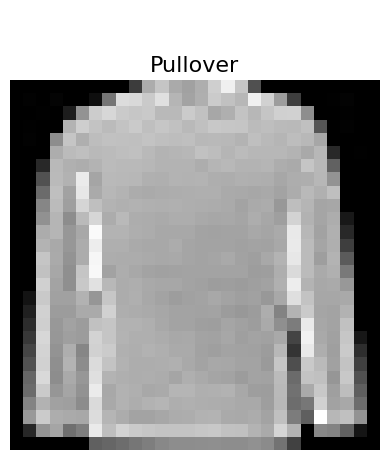

In [14]:
def show(idx, title):
  plt.figure()
  plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
  plt.axis('off')
  plt.title('\n\n{}'.format(title), fontdict={'size': 16})


i = np.random.randint(0, len(x_test))
show(i, labels[y_test[i]])

In [15]:
# Format some data to pass to the server
# {
#   "signature_name": "serving_default",
#   "instances": [ an N x H x W x C list ],
# }

import json
data = json.dumps({"signature_name": "serving_default",
                  "instances": x_test[0:3].tolist()})
print(data)

{"signature_name": "serving_default", "instances": [[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], 

In [16]:
headers = {"content-type": "application/json"}
r = requests.post(
    'http://localhost:8501/v1/models/fashion_model:predict', data=data, headers=headers)
j = r.json()
print(j.keys())
print(j)

dict_keys(['predictions'])
{'predictions': [[2.3260282e-14, 1.3229801e-17, 1.94049334e-12, 1.3494153e-14, 1.77184303e-13, 3.98865154e-07, 3.13309708e-13, 1.23567512e-09, 3.74328847e-16, 0.999999642], [3.4805289e-05, 1.51574771e-08, 0.998262227, 0.000739193289, 0.000623567088, 2.79323054e-08, 0.000338993268, 1.77391115e-08, 9.63937509e-07, 1.58480191e-07], [3.93005253e-37, 1.0, 0.0, 0.0, 1.31540827e-30, 0.0, 0.0, 0.0, 0.0, 0.0]]}


In [17]:
# It looks like a 2-D array, let's check its shape
pred = np.array(j['predictions'])
print(pred.shape)

# This is the N x K output array from the model
# pred[n,k] is the probability that we believe the nth sample belongs to the kth class

(3, 10)


In [18]:
# Get the predicted classes
pred = pred.argmax(axis=1)

In [19]:
# Map them back to strings
pred = [labels[i] for i in pred]
print(pred)

['Ankle boot', 'Pullover', 'Trouser']


In [20]:
# Get the true labels
actual = [labels[i] for i in y_test[:3]]
print(actual)

['Ankle boot', 'Pullover', 'Trouser']


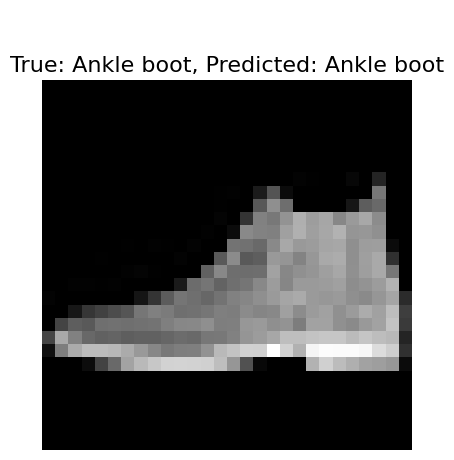

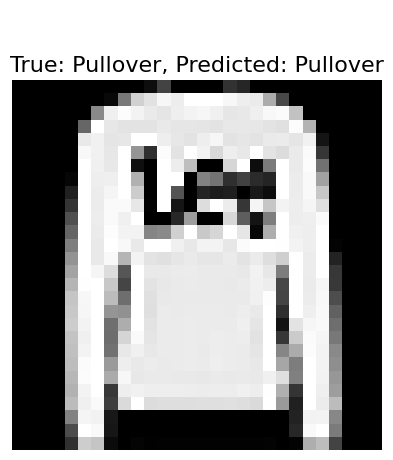

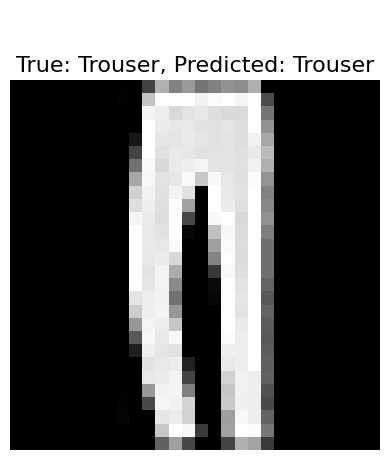

In [21]:
for i in range(0, 3):
  show(i, f"True: {actual[i]}, Predicted: {pred[i]}")

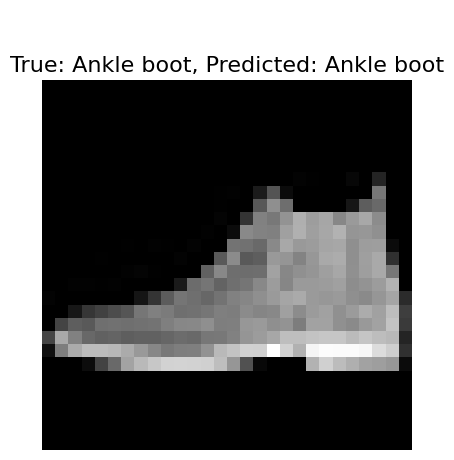

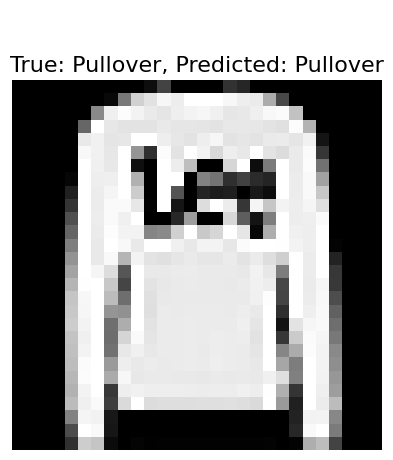

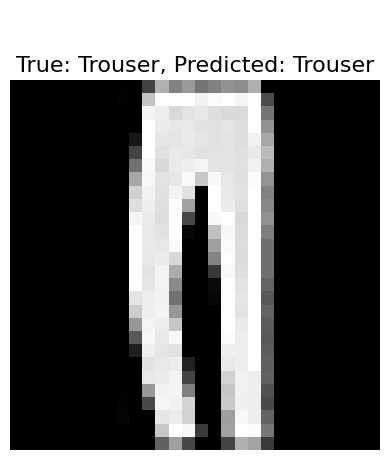

In [22]:
# Allows you to select a model by version

headers = {"content-type": "application/json"}
r = requests.post(
    'http://localhost:8501/v1/models/fashion_model/versions/1:predict', data=data, headers=headers)
j = r.json()
pred = np.array(j['predictions'])
pred = pred.argmax(axis=1)
pred = [labels[i] for i in pred]
for i in range(0, 3):
  show(i, f"True: {actual[i]}, Predicted: {pred[i]}")

In [23]:
# Let's make a new model version
# Build the model using the functional API
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Flatten()(x)
x = Dense(K, activation='softmax')(x)

model2 = Model(i, x)
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile and fit
# Note: make sure you are using the GPU for this!
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
r = model2.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8393 - loss: 0.4604 - val_accuracy: 0.8699 - val_loss: 0.3771
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.8848 - loss: 0.3248 - val_accuracy: 0.8760 - val_loss: 0.3437
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 937us/step - accuracy: 0.8961 - loss: 0.2908 - val_accuracy: 0.8866 - val_loss: 0.3199
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 914us/step - accuracy: 0.9031 - loss: 0.2695 - val_accuracy: 0.8854 - val_loss: 0.3132
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 917us/step - accuracy: 0.9090 - loss: 0.2541 - val_accuracy: 0.8810 - val_loss: 0.3170
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - accuracy: 0.9132 - loss: 0.2416 - val_accuracy: 0.8896 - val_loss: 0.3049
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - accuracy: 0.9176 - loss: 0.2301 - val_accuracy: 0.8928 - val_loss: 0.2985
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.9207 - l

In [25]:
# Save version 2 of the model

version = 2
export_path = os.path.join(MODEL_DIR, str(version))
print('export_path = {}\n'.format(export_path))
if os.path.isdir(export_path):
  print('\nAlready saved a model, cleaning up\n')
  !rm -r {export_path}

model2.export(export_path)

print('\nSaved model:')
!ls -l {export_path}

export_path = /tmp/2

INFO:tensorflow:Assets written to: /tmp/2/assets


INFO:tensorflow:Assets written to: /tmp/2/assets


Saved artifact at '/tmp/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  125238279616080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238279616848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238279617808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125238279617040: TensorSpec(shape=(), dtype=tf.resource, name=None)

Saved model:
total 48
drwxr-xr-x 2 ahsan ahsan  4096 Feb  3 12:01 assets
-rw-rw-r-- 1 ahsan ahsan    98 Feb  3 12:01 fingerprint.pb
-rw-rw-r-- 1 ahsan ahsan 35414 Feb  3 12:01 saved_model.pb
drwxr-xr-x 2 ahsan ahsan  4096 Feb  3 12:01 variables


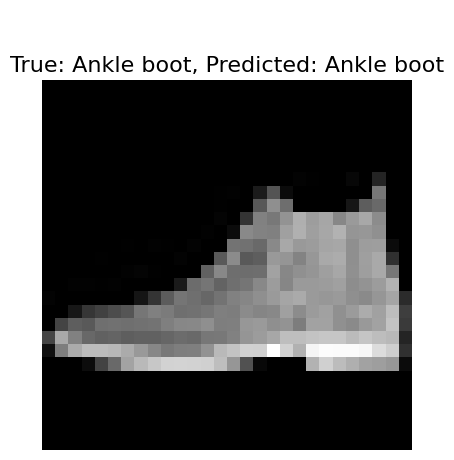

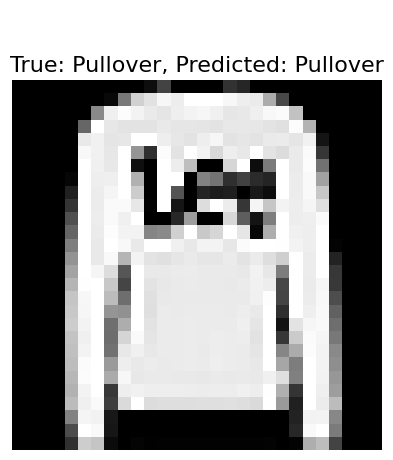

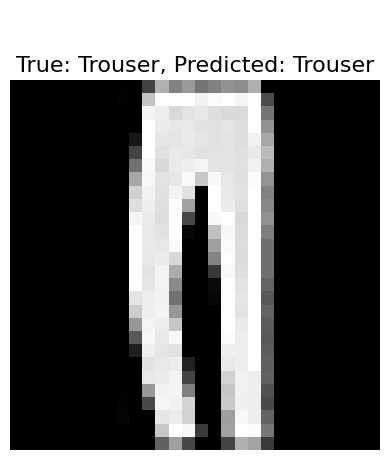

In [26]:
# Will Tensorflow serving know about the new model without restarting?

headers = {"content-type": "application/json"}
r = requests.post(
    'http://localhost:8501/v1/models/fashion_model/versions/2:predict', data=data, headers=headers)
j = r.json()
pred = np.array(j['predictions'])
pred = pred.argmax(axis=1)
pred = [labels[i] for i in pred]
for i in range(0, 3):
  show(i, f"True: {actual[i]}, Predicted: {pred[i]}")

In [27]:
# What if we use a version number that does not exist?
headers = {"content-type": "application/json"}
r = requests.post(
    'http://localhost:8501/v1/models/fashion_model/versions/3:predict', data=data, headers=headers)
j = r.json()
print(j)

{'error': 'Servable not found for request: Specific(fashion_model, 3)'}
